EDA for Dashboard 3

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
fact_sales = pd.read_csv('/content/fact_sales.csv')
dim_date = pd.read_csv('/content/dim_date.csv')
dim_product = pd.read_csv('/content/dim_product.csv')
dim_market = pd.read_csv('/content/dim_marketplace.csv')

In [3]:
fact_sales.columns

Index(['Sales_Key', 'Date_Key', 'Marketplace_Key', 'Product_Key',
       'Account Title', 'Taxes', 'Orders', 'Units', 'Refunded', 'Refund %',
       'Unit Session %', 'Promo Units', 'Organic Units', 'Per Unit Revenue',
       'Revenue', 'COGS', 'FBA Fees', 'Promo Amount', 'Sessions', 'Page Views',
       'Impressions', 'Clicks', 'PPC Orders', 'PPC Sales', 'PPC Cost',
       'PPC Conv', 'OOE', 'Net Profit', 'Net Margin', 'Net ROI'],
      dtype='object')

In [5]:
dim_market.columns

Index(['Marketplace_Key', 'Market Place', 'Account Title'], dtype='object')

In [6]:
dim_date.columns

Index(['Date_Key', 'Date', 'Day', 'Month', 'Month_Name', 'Quarter', 'Year',
       'Week_Of_Year', 'Day_Name', 'Is_Weekend'],
      dtype='object')

In [7]:
dim_product.columns

Index(['Product_Key', 'SKU', 'FNSKU', 'ASIN', 'Parent ASIN', 'Is Parent',
       'Brand', 'Title'],
      dtype='object')

In [8]:
df = fact_sales.merge(dim_market,on='Marketplace_Key',how='left')

df = df.merge(dim_date,on='Date_Key',how='left')

df = df.merge(dim_product,on='Product_Key',how='left')

In [9]:
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

Rows: 13323
Columns: 48


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13323 entries, 0 to 13322
Data columns (total 48 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Sales_Key         13323 non-null  int64  
 1   Date_Key          13323 non-null  int64  
 2   Marketplace_Key   13323 non-null  int64  
 3   Product_Key       13323 non-null  int64  
 4   Account Title_x   13323 non-null  object 
 5   Taxes             13323 non-null  float64
 6   Orders            13323 non-null  int64  
 7   Units             13323 non-null  int64  
 8   Refunded          13323 non-null  int64  
 9   Refund %          13323 non-null  float64
 10  Unit Session %    13323 non-null  float64
 11  Promo Units       13323 non-null  int64  
 12  Organic Units     13323 non-null  int64  
 13  Per Unit Revenue  13323 non-null  float64
 14  Revenue           13323 non-null  float64
 15  COGS              13323 non-null  float64
 16  FBA Fees          13323 non-null  float6

In [11]:
df.isnull().sum()

,0
Sales_Key,0
Date_Key,0
Marketplace_Key,0
Product_Key,0
Account Title_x,0
Taxes,0
Orders,0
Units,0
Refunded,0
Refund %,0


1-Revenue Analysis

In [12]:
total_revenue = df['Revenue'].sum()

print("Total Revenue =",total_revenue)

Total Revenue = 3628133.7699999996


In [13]:
revenue_market = (
    df.groupby('Market Place')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

revenue_market

,Revenue
Market Place,
DE,1151257.96
ES,1111192.69
IT,589495.20
UK,566358.12
FR,209829.80


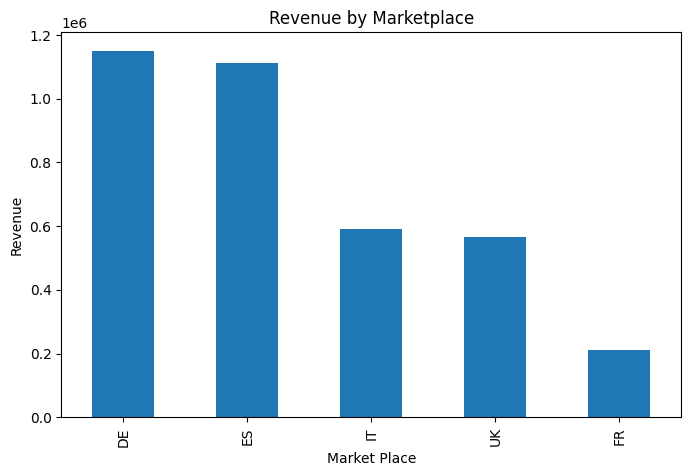

In [14]:
plt.figure(figsize=(8,5))

revenue_market.plot(kind='bar')

plt.title("Revenue by Marketplace")
plt.ylabel("Revenue")

plt.show()

2-Orders Analysis

In [15]:
orders_market = (
    df.groupby('Market Place')['Orders']
    .sum()
    .sort_values(ascending=False)
)

orders_market

,Orders
Market Place,
DE,45988
ES,45381
UK,27396
IT,23919
FR,8480


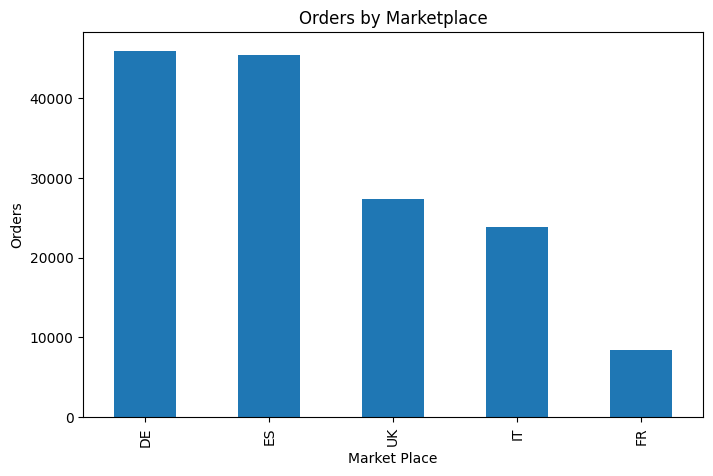

In [16]:
plt.figure(figsize=(8,5))

orders_market.plot(kind='bar')

plt.title("Orders by Marketplace")
plt.ylabel("Orders")

plt.show()

3-Units Sold Analysis

In [17]:
units_market = (
    df.groupby('Market Place')['Units']
    .sum()
    .sort_values(ascending=False)
)

units_market

,Units
Market Place,
DE,55390
ES,52445
UK,30880
IT,28012
FR,10450


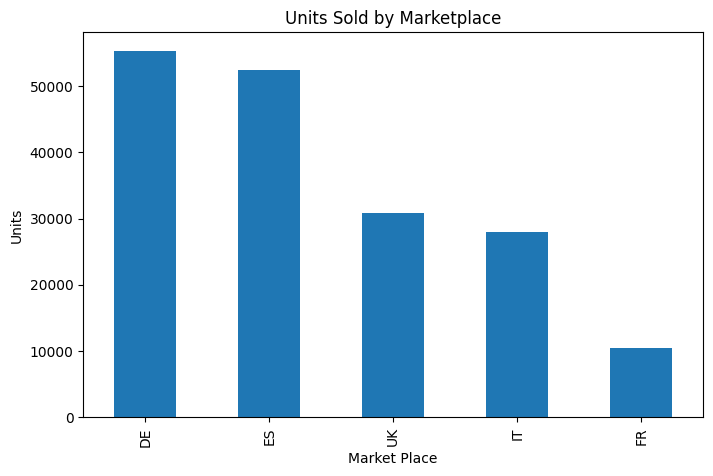

In [18]:
plt.figure(figsize=(8,5))

units_market.plot(kind='bar')

plt.title("Units Sold by Marketplace")
plt.ylabel("Units")

plt.show()

4-Net Profit Analysis

In [19]:
profit_market = (
    df.groupby('Market Place')['Net Profit']
    .sum()
    .sort_values(ascending=False)
)

profit_market

,Net Profit
Market Place,
DE,333395.70
ES,260852.48
IT,105717.83
UK,78125.58
FR,37598.64


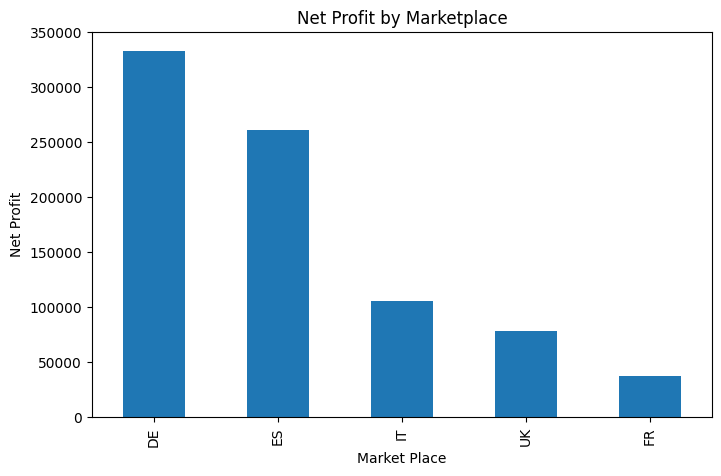

In [20]:
plt.figure(figsize=(8,5))

profit_market.plot(kind='bar')

plt.title("Net Profit by Marketplace")
plt.ylabel("Net Profit")

plt.show()

5-Average Net Margin

In [21]:
margin_market = (
    df.groupby('Market Place')['Net Margin']
    .mean()
    .sort_values(ascending=False)
)

margin_market

,Net Margin
Market Place,
UK,4.542503e+12
DE,2.439859e-01
ES,2.045839e-01
IT,1.117406e-01
FR,-3.436943e+12


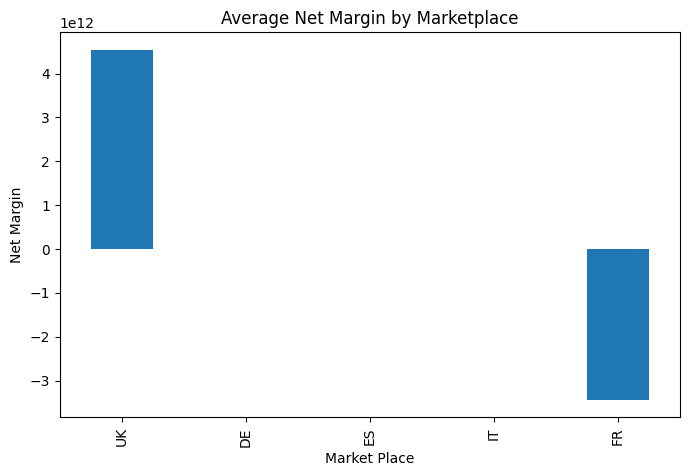

In [22]:
plt.figure(figsize=(8,5))

margin_market.plot(kind='bar')

plt.title("Average Net Margin by Marketplace")
plt.ylabel("Net Margin")

plt.show()

6-Revenue Contribution

In [23]:
market_share = (
    df.groupby('Market Place')['Revenue']
    .sum()
)

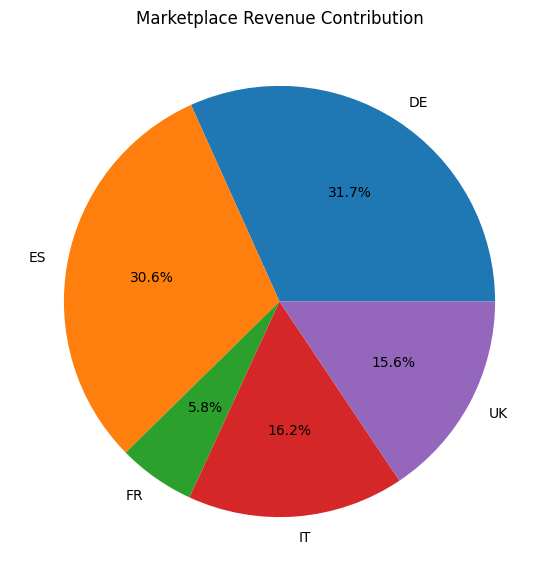

In [24]:
plt.figure(figsize=(7,7))

market_share.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Marketplace Revenue Contribution")
plt.ylabel("")

plt.show()

7-Revenue Trend Over Time

In [26]:
monthly_revenue = (
    df.groupby(['Year','Month'])['Revenue']
    .sum()
)
monthly_revenue

Year  Month
2020  10       556418.12
      11       567418.18
      12       421130.36
2021  1        561266.13
      2        496282.89
      3        553953.23
      4        471664.86
Name: Revenue, dtype: float64

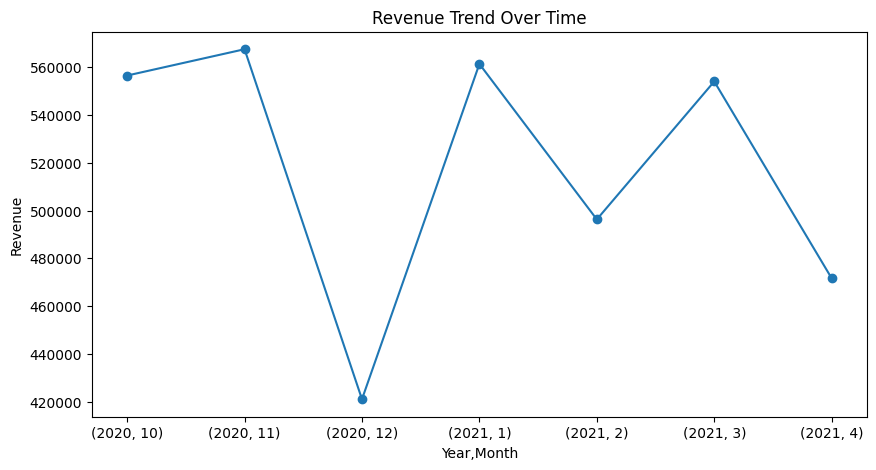

In [27]:
monthly_revenue.plot(
    figsize=(10,5),
    marker='o'
)

plt.title("Revenue Trend Over Time")
plt.ylabel("Revenue")

plt.show()

8-Best Marketplace

In [28]:
best_market = (
    df.groupby('Market Place')['Revenue']
    .sum()
    .idxmax()
)

print("Best Marketplace =",best_market)

Best Marketplace = DE


9-ROI by Marketplace

In [29]:
roi_market = (
    df.groupby('Market Place')['Net ROI']
    .mean()
    .sort_values(ascending=False)
)

roi_market

,Net ROI
Market Place,
DE,0.450536
ES,0.387646
UK,0.194663
FR,0.187562
IT,0.186036


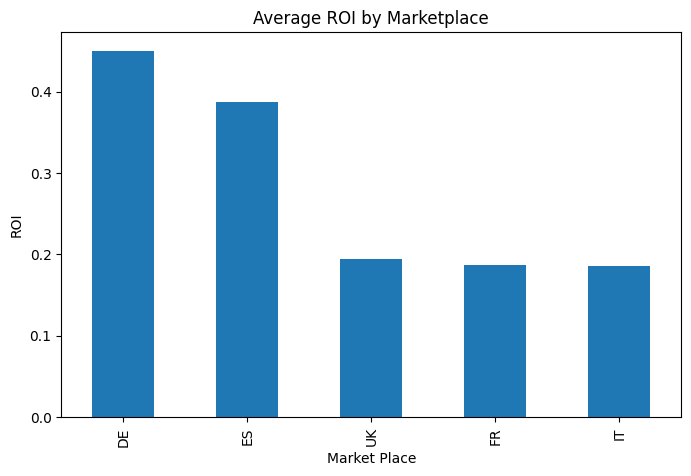

In [30]:
plt.figure(figsize=(8,5))

roi_market.plot(kind='bar')

plt.title("Average ROI by Marketplace")
plt.ylabel("ROI")

plt.show()

10-Multi-Marketplace Performance Trend

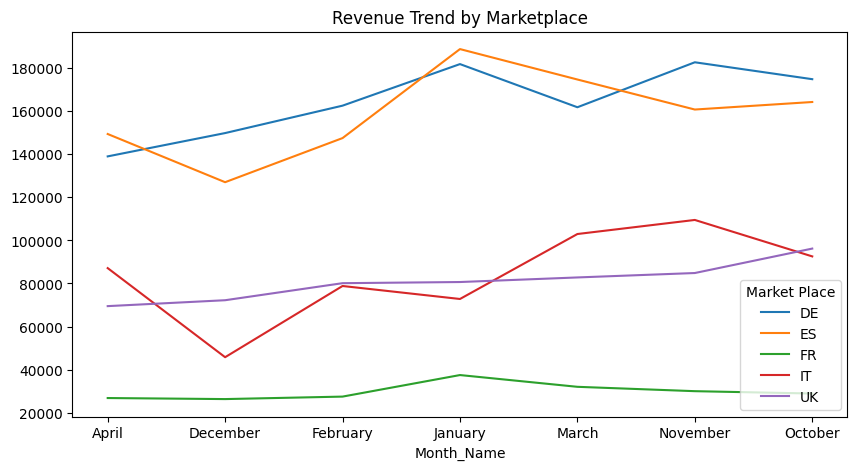

In [31]:
trend = df.groupby(['Month_Name','Market Place'])['Revenue'].sum().unstack()
trend.plot(figsize=(10,5))
plt.title("Revenue Trend by Marketplace")
plt.show()

11-Profitability by Day of Week

In [32]:
heatmap_data = df.pivot_table(
    values='Net Profit',
    index='Market Place',
    columns='Day_Name',
    aggfunc='sum'
)

heatmap_data

Day_Name,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
Market Place,,,,,,,
DE,41017.14,56244.78,39384.05,52741.96,46754.28,49452.73,47800.76
ES,32711.43,42986.97,31575.51,39874.20,37159.41,38887.31,37657.65
FR,4849.73,6102.18,4839.99,5527.20,5174.45,5507.14,5597.95
IT,12648.40,17838.11,13418.24,16332.39,15080.67,15340.25,15059.77
UK,11222.56,12583.94,10805.00,12117.46,11646.50,10164.45,9585.67


12-Cost Breakdown by Marketplace

In [33]:
costs = df.groupby('Market Place')[
    ['COGS','FBA Fees','PPC Cost','Net Profit']
].sum()

costs

,COGS,FBA Fees,PPC Cost,Net Profit
Market Place,,,,
DE,-302104.42,-323982.95,-59727.71,333395.70
ES,-318847.72,-326787.65,-70939.33,260852.48
FR,-62106.41,-75575.96,-12471.72,37598.64
IT,-170817.44,-193746.67,-32602.67,105717.83
UK,-216612.22,-172932.10,-27391.35,78125.58


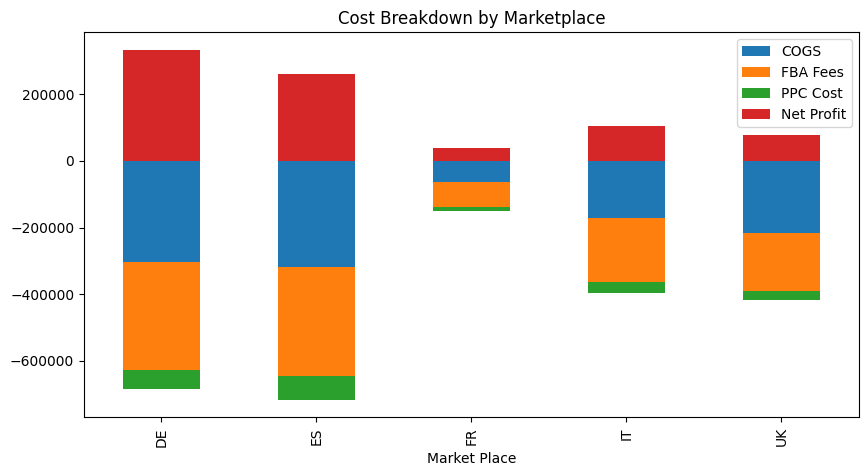

In [34]:
costs.plot(
    kind='bar',
    stacked=True,
    figsize=(10,5)
)

plt.title("Cost Breakdown by Marketplace")
plt.show()